<a href="https://colab.research.google.com/github/vikamaslancuk5-commits/Sales-Logistics-Data-Analysis-/blob/main/Sales_%26_Logistics_Data_Analysis_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

%matplotlib inline

drive.mount("/content/drive")

%cd /content/drive/MyDrive/Mate

countries = pd.read_csv("countries.csv")
events = pd.read_csv("events.с.csv")
products = pd.read_csv("products.c")

Mounted at /content/drive
/content/drive/MyDrive/Mate


In [ ]:
events.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


In [ ]:
countries.head()

,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


In [ ]:
products.head()

,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


##Data cleaning. Робота із пропущеними даними, некоректними даними, аномаліями.

In [ ]:
# Перевіряємо інформацію
print("EVENTS")
events.info()
print("-" * 40)
print("COUNTRIES")
countries.info()
print("-" * 40)
print("PRODUCTS")
products.info()

EVENTS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB
----------------------------------------
COUNTRIES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   al

In [ ]:
# Тип даних
print("EVENTS DTYPES")
print(events.dtypes)
print("-" * 40)

print("COUNTRIES DTYPES")
print(countries.dtypes)
print("-" * 40)

print("PRODUCTS DTYPES")
print(products.dtypes)

EVENTS DTYPES
Order ID            int64
Order Date         object
Ship Date          object
Order Priority     object
Country Code       object
Product ID          int64
Sales Channel      object
Units Sold        float64
Unit Price        float64
Unit Cost         float64
dtype: object
----------------------------------------
COUNTRIES DTYPES
name          object
alpha-2       object
alpha-3       object
region        object
sub-region    object
dtype: object
----------------------------------------
PRODUCTS DTYPES
id            int64
item_type    object
dtype: object


In [ ]:
# Описова статистика
events[["Units Sold", "Unit Price", "Unit Cost"]].describe()

,Units Sold,Unit Price,Unit Cost
count,1328.000000,1330.000000,1330.000000
mean,4952.201807,264.893541,187.246812
std,2905.198996,217.323460,176.158873
min,2.000000,9.330000,6.920000
25%,2356.750000,81.730000,35.840000
50%,4962.000000,154.060000,97.440000
75%,7459.500000,437.200000,263.330000
max,9999.000000,668.270000,524.960000


In [ ]:
# Кількість пропущених значень
print("EVENTS")
print(events.isna().sum())
print("-" * 40)
print("COUNTRIES")
print(countries.isna().sum())
print("-" * 40)
print("PRODUCTS")
print(products.isna().sum())

EVENTS
Order ID           0
Order Date         0
Ship Date          0
Order Priority     0
Country Code      82
Product ID         0
Sales Channel      0
Units Sold         2
Unit Price         0
Unit Cost          0
dtype: int64
----------------------------------------
COUNTRIES
name          0
alpha-2       1
alpha-3       0
region        1
sub-region    1
dtype: int64
----------------------------------------
PRODUCTS
id           0
item_type    0
dtype: int64


In [ ]:
# Відсоток пропущених значень
events.isna().sum() / events.shape[0] * 100
print("EVENTS")
print(events.isna().sum() / events.shape[0] * 100)
print("-" * 40)
print("COUNTRIES")
print(countries.isna().sum() / events.shape[0] * 100)


EVENTS
Order ID          0.000000
Order Date        0.000000
Ship Date         0.000000
Order Priority    0.000000
Country Code      6.165414
Product ID        0.000000
Sales Channel     0.000000
Units Sold        0.150376
Unit Price        0.000000
Unit Cost         0.000000
dtype: float64
----------------------------------------
COUNTRIES
name          0.000000
alpha-2       0.075188
alpha-3       0.000000
region        0.075188
sub-region    0.075188
dtype: float64


In [ ]:
# Заміна пропущених значень
events["Country Code"] = events["Country Code"].fillna("Unknown")
events["Units Sold"] = events["Units Sold"].fillna(events["Units Sold"].median())

countries = countries.dropna()
# Перевірка
print("Пропуски після очищення:")
print("EVENTS:",   events.isna().sum().sum())
print("PRODUCTS:", products.isna().sum().sum())
print("COUNTRIES:", countries.isna().sum().sum())

Пропуски після очищення:
EVENTS: 0
PRODUCTS: 0
COUNTRIES: 0


In [ ]:
# Знаходження дублікатів
print("EVENTS")
print(events.duplicated())
print("-" * 40)
print("COUNTRIES")
print(countries.duplicated())
print("-" * 40)
print("PRODUCTS")
print(products.duplicated())

EVENTS
0       False
1       False
2       False
3       False
4       False
        ...  
1325    False
1326    False
1327    False
1328    False
1329    False
Length: 1330, dtype: bool
----------------------------------------
COUNTRIES
0      False
1      False
2      False
3      False
4      False
       ...  
244    False
245    False
246    False
247    False
248    False
Length: 247, dtype: bool
----------------------------------------
PRODUCTS
0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
dtype: bool


In [ ]:
# Перетворення даних
events["Order Date"] = pd.to_datetime(events["Order Date"])
events["Ship Date"] = pd.to_datetime(events["Ship Date"])
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1330 non-null   int64         
 1   Order Date      1330 non-null   datetime64[ns]
 2   Ship Date       1330 non-null   datetime64[ns]
 3   Order Priority  1330 non-null   object        
 4   Country Code    1330 non-null   object        
 5   Product ID      1330 non-null   int64         
 6   Sales Channel   1330 non-null   object        
 7   Units Sold      1330 non-null   float64       
 8   Unit Price      1330 non-null   float64       
 9   Unit Cost       1330 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(3)
memory usage: 104.0+ KB


In [ ]:
# Нормалізація
events.columns = events.columns.str.lower().str.replace(" ", "_")
products.columns = products.columns.str.lower().str.replace(" ", "_")
countries.columns = countries.columns.str.lower().str.replace(" ", "_")

In [ ]:
# Нормалізація рядкових колонок
for df in [events, products, countries]:
    for col in df.select_dtypes(include='object').columns:
        df.loc[:, col] = df[col].str.strip().str.lower()

In [ ]:
# Заміна схожих кириличних літер на латинські
LOOKALIKES = str.maketrans('аеорсхАВЕОРСХ', 'aeopсxABEOPCX')
for df in [events, products, countries]:
    for col in df.select_dtypes(include='object').columns:
        df.loc[:, col] = df[col].str.translate(LOOKALIKES)

In [ ]:
# Аномалії методом IQR по кожній числовій колонці
for col in events.select_dtypes(include=np.number).columns:
    Q1 = events[col].quantile(0.25)
    Q3 = events[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((events[col] < Q1 - 1.5 * IQR) | (events[col] > Q3 + 1.5 * IQR)).sum()
    print(f"[{col}] аномалій: {outliers} ({outliers / len(events) * 100:.1f}%)")

[order_id] аномалій: 0 (0.0%)
[product_id] аномалій: 0 (0.0%)
[units_sold] аномалій: 0 (0.0%)
[unit_price] аномалій: 0 (0.0%)
[unit_cost] аномалій: 0 (0.0%)


#Data analysis and visualization. Аналіз та візуалізація даних, знаходження цінних інсайтів.

In [ ]:
merged_df = events.merge(products, left_on="product_id", right_on="id", how="left")

merged_df = merged_df.merge(countries, left_on="country_code", right_on="alpha-3", how="left")

merged_df = merged_df.rename(columns={"name": "country_name","item_type": "product_type"})

merged_df = merged_df.drop(columns=["id", "alpha_2", "alpha-2", "country_code"], errors="ignore")

merged_df["country_name"] = merged_df["country_name"].fillna("unknown")
merged_df["alpha-3"] = merged_df["alpha-3"].fillna("unknown")
merged_df["region"] = merged_df["region"].fillna("unknown")
merged_df["sub-region"] = merged_df["sub-region"].fillna("unknown")

merged_df.head()

,order_id,order_date,ship_date,order_priority,product_id,sales_channel,units_sold,unit_price,unit_cost,product_type,country_name,alpha-3,region,sub-region
0,100640618,2014-10-08,2014-10-18,m,2103,online,650.0,205.70,117.11,cereal,norway,nor,europe,northern europe
1,100983083,2016-08-11,2016-08-11,c,2103,offline,1993.0,205.70,117.11,cereal,serbia,srb,europe,southern europe
2,101025998,2014-07-18,2014-08-11,m,7940,online,4693.0,668.27,502.54,household,unknown,unknown,unknown,unknown
3,102230632,2017-05-13,2017-06-13,l,2455,online,1171.0,109.28,35.84,clothes,montenegro,mne,europe,southern europe
4,103435266,2012-08-11,2012-09-18,h,1270,offline,7648.0,47.45,31.79,beverages,serbia,srb,europe,southern europe


In [ ]:
total_orders = merged_df["order_id"].count()

revenue = (merged_df["units_sold"] * merged_df["unit_price"]).sum()

total_cost = (merged_df["units_sold"] * merged_df["unit_cost"]).sum()

total_profit = revenue - total_cost

total_countries = merged_df["country_name"].nunique()

print(f"Загальна кількість замовлень: {total_orders}")
print(f"Загальна виручка: ${revenue:,.2f}")
print(f"Загальна собівартість: ${total_cost:,.2f}")
print(f"Чистий прибуток: ${total_profit:,.2f}")
print(f"Загальна кількість кріїн: {total_countries}")


Загальна кількість замовлень: 1330
Загальна виручка: $1,704,628,370.65
Загальна собівартість: $1,202,785,737.53
Чистий прибуток: $501,842,633.12
Загальна кількість кріїн: 46


In [ ]:
merged_df["revenue"] = (merged_df["units_sold"] * merged_df["unit_price"])

merged_df["cost"] = (merged_df["units_sold"] * merged_df["unit_cost"])

merged_df["profit"] = merged_df["revenue"] - merged_df["cost"]

print(merged_df.head())

    order_id order_date  ship_date order_priority  product_id sales_channel  \
0  100640618 2014-10-08 2014-10-18              m        2103        online   
1  100983083 2016-08-11 2016-08-11              c        2103       offline   
2  101025998 2014-07-18 2014-08-11              m        7940        online   
3  102230632 2017-05-13 2017-06-13              l        2455        online   
4  103435266 2012-08-11 2012-09-18              h        1270       offline   

   units_sold  unit_price  unit_cost product_type country_name  alpha-3  \
0       650.0      205.70     117.11       cereal       norway      nor   
1      1993.0      205.70     117.11       cereal       serbia      srb   
2      4693.0      668.27     502.54    household      unknown  unknown   
3      1171.0      109.28      35.84      clothes   montenegro      mne   
4      7648.0       47.45      31.79    beverages       serbia      srb   

    region       sub-region     revenue        cost     profit  
0   europ

##Продажі в розрізі категорії товарів

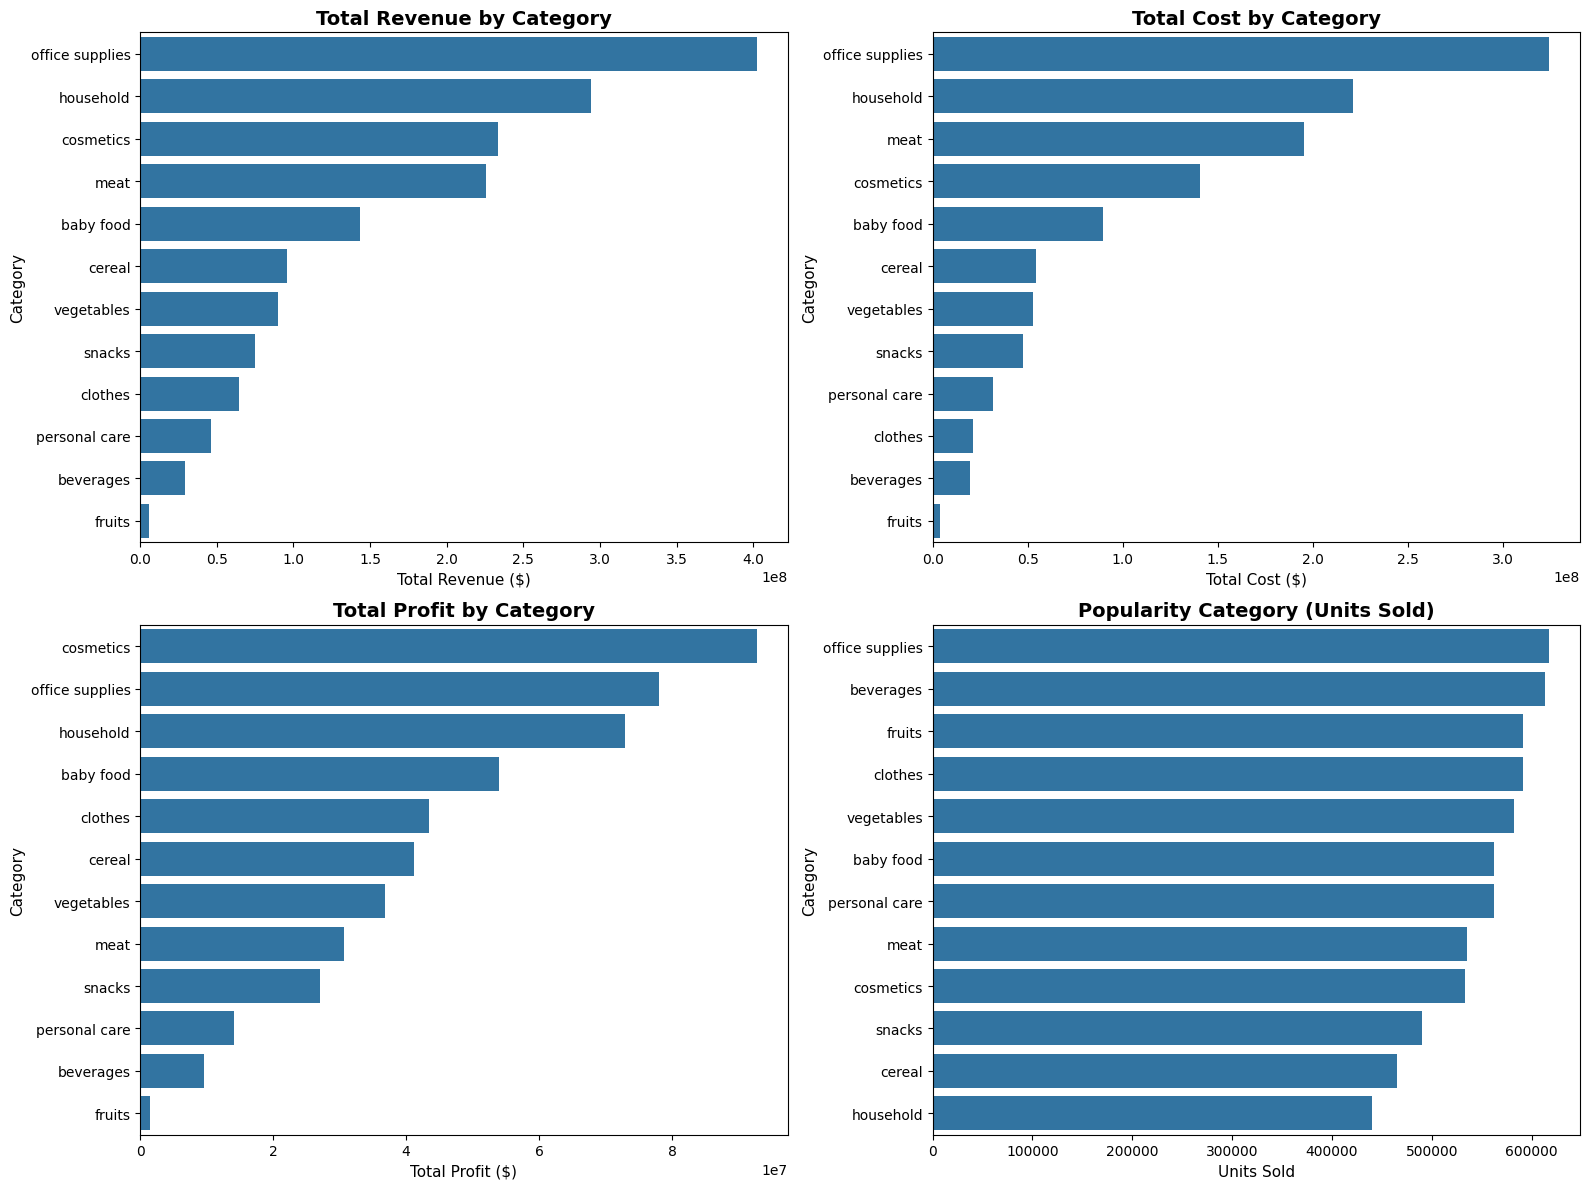

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(16, 12))

# TOTAL REVENUE
rev_df = (merged_df.groupby("product_type")["revenue"].sum().sort_values(ascending=False).reset_index())
sns.barplot(x="revenue", y="product_type", data=rev_df, errorbar=None, ax=ax[0, 0])
ax[0, 0].set_title("Total Revenue by Category", fontsize=14, fontweight="bold")
ax[0, 0].set_xlabel("Total Revenue ($)", fontsize=11)
ax[0, 0].set_ylabel("Category", fontsize=11)

#TOTAL COST
cost_df = (merged_df.groupby("product_type")["cost"].sum().sort_values(ascending=False).reset_index())
sns.barplot(x="cost", y="product_type", data=cost_df, errorbar=None, ax=ax[0, 1])
ax[0, 1].set_title("Total Cost by Category", fontsize=14, fontweight="bold")
ax[0, 1].set_xlabel("Total Cost ($)", fontsize=11)
ax[0, 1].set_ylabel("Category", fontsize=11)

#TOTAL PROFIT
profit_df = (merged_df.groupby("product_type")["profit"].sum().sort_values(ascending=False).reset_index())
sns.barplot(x="profit", y="product_type", data=profit_df, errorbar=None, ax=ax[1, 0])
ax[1, 0].set_title("Total Profit by Category", fontsize=14, fontweight="bold")
ax[1, 0].set_xlabel("Total Profit ($)", fontsize=11)
ax[1, 0].set_ylabel("Category", fontsize=11)

# UNITS SOLD
sold_df = (merged_df.groupby("product_type")["units_sold"].sum().sort_values(ascending=False).reset_index())
sns.barplot(x="units_sold", y="product_type", data=sold_df, errorbar=None, ax=ax[1, 1])
ax[1, 1].set_title("Popularity Category (Units Sold)", fontsize=14, fontweight="bold")
ax[1, 1].set_xlabel("Units Sold", fontsize=11)
ax[1, 1].set_ylabel("Category", fontsize=11)

plt.tight_layout()

plt.show()

##Продажі в розрізі країн

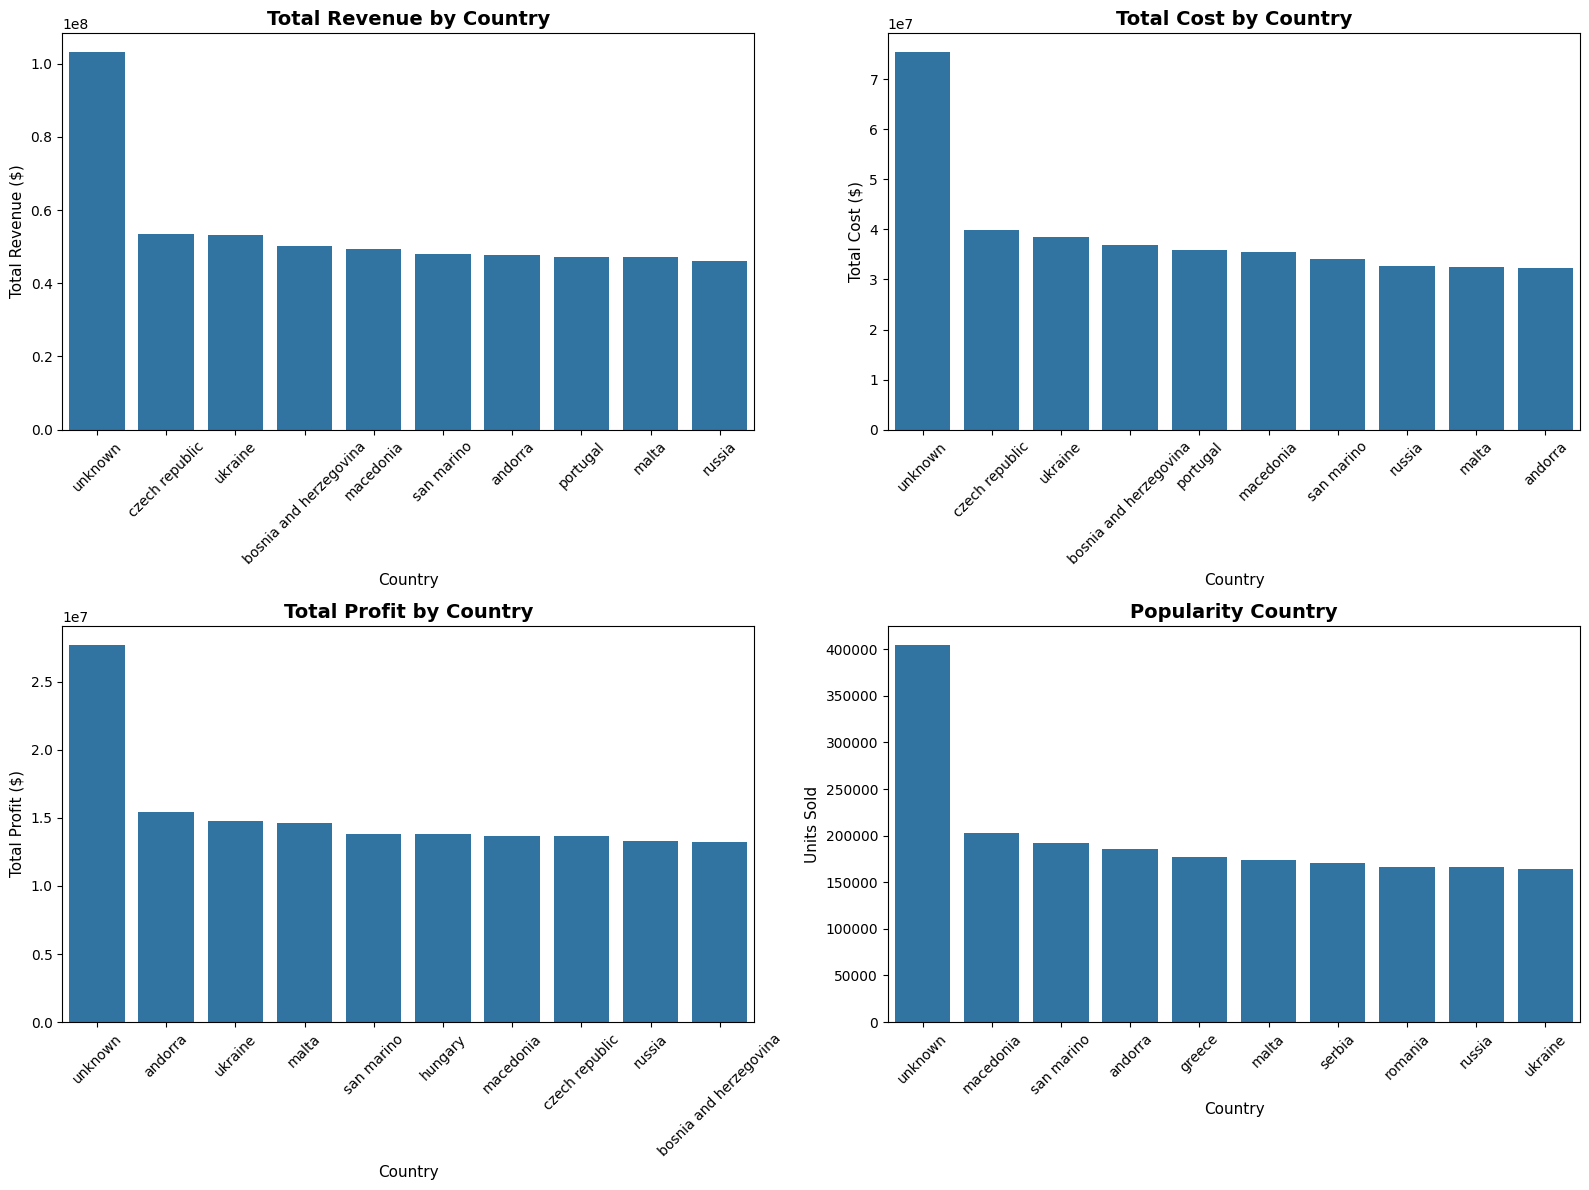

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(16, 12))

# TOTAL REVENUE
rev_df = merged_df.groupby("country_name")["revenue"].sum().sort_values(ascending=False).head(10).reset_index()
sns.barplot(x="country_name", y="revenue", data=rev_df, errorbar=None, ax=ax[0, 0])
ax[0, 0].set_title("Total Revenue by Country", fontsize=14, fontweight="bold")
ax[0, 0].set_xlabel("Country", fontsize=11)
ax[0, 0].set_ylabel("Total Revenue ($)", fontsize=11)
ax[0, 0].tick_params(axis="x", rotation=45)

#TOTAL COST
cost_df = merged_df.groupby("country_name")["cost"].sum().sort_values(ascending=False).head(10).reset_index()
sns.barplot(x="country_name", y="cost", data=cost_df, errorbar=None, ax=ax[0, 1])
ax[0, 1].set_title("Total Cost by Country", fontsize=14, fontweight="bold")
ax[0, 1].set_xlabel("Country", fontsize=11)
ax[0, 1].set_ylabel("Total Cost ($)", fontsize=11)
ax[0, 1].tick_params(axis="x", rotation=45)

#TOTAL PROFIT
profit_df = merged_df.groupby("country_name")["profit"].sum().sort_values(ascending=False).head(10).reset_index()
sns.barplot(x="country_name", y="profit", data=profit_df, errorbar=None, ax=ax[1, 0])
ax[1, 0].set_title("Total Profit by Country", fontsize=14, fontweight="bold")
ax[1, 0].set_xlabel("Country", fontsize=11)
ax[1, 0].set_ylabel("Total Profit ($)", fontsize=11)
ax[1, 0].tick_params(axis="x", rotation=45)

# UNITS SOLD
sold_df = merged_df.groupby("country_name")["units_sold"].sum().sort_values(ascending=False).head(10).reset_index()
sns.barplot(x="country_name", y="units_sold", data=sold_df, errorbar=None, ax=ax[1, 1])
ax[1, 1].set_title("Popularity Country", fontsize=14, fontweight="bold")
ax[1, 1].set_xlabel("Country", fontsize=11)
ax[1, 1].set_ylabel("Units Sold", fontsize=11)
ax[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()

plt.show()

##Продажі в розрізі регіонів

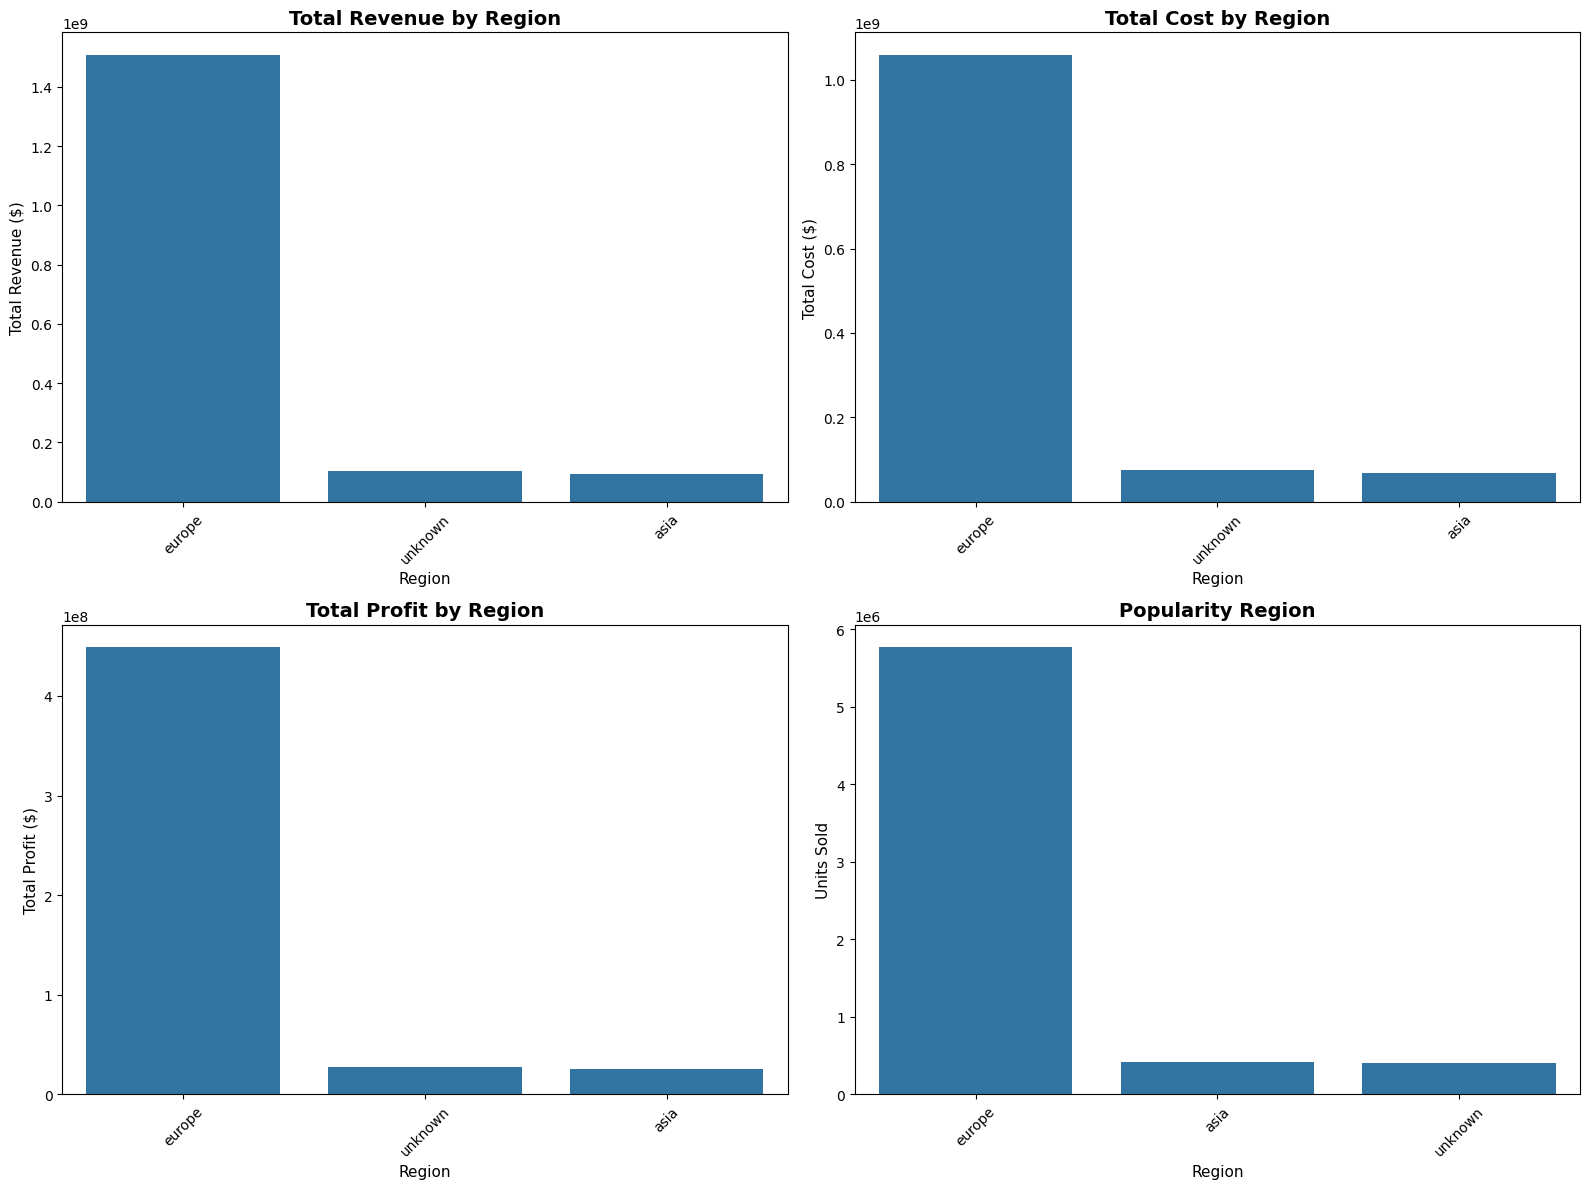

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(16, 12))

# TOTAL REVENUE
rev_df = merged_df.groupby("region")["revenue"].sum().sort_values(ascending=False).head(10).reset_index()
sns.barplot(x="region", y="revenue", data=rev_df, errorbar=None, ax=ax[0, 0])
ax[0, 0].set_title("Total Revenue by Region", fontsize=14, fontweight="bold")
ax[0, 0].set_xlabel("Region", fontsize=11)
ax[0, 0].set_ylabel("Total Revenue ($)", fontsize=11)
ax[0, 0].tick_params(axis="x", rotation=45)

#TOTAL COST
cost_df = merged_df.groupby("region")["cost"].sum().sort_values(ascending=False).head(10).reset_index()
sns.barplot(x="region", y="cost", data=cost_df, errorbar=None, ax=ax[0, 1])
ax[0, 1].set_title("Total Cost by Region", fontsize=14, fontweight="bold")
ax[0, 1].set_xlabel("Region", fontsize=11)
ax[0, 1].set_ylabel("Total Cost ($)", fontsize=11)
ax[0, 1].tick_params(axis="x", rotation=45)

#TOTAL PROFIT
profit_df = merged_df.groupby("region")["profit"].sum().sort_values(ascending=False).head(10).reset_index()
sns.barplot(x="region", y="profit", data=profit_df, errorbar=None, ax=ax[1, 0])
ax[1, 0].set_title("Total Profit by Region", fontsize=14, fontweight="bold")
ax[1, 0].set_xlabel("Region", fontsize=11)
ax[1, 0].set_ylabel("Total Profit ($)", fontsize=11)
ax[1, 0].tick_params(axis="x", rotation=45)

# UNITS SOLD
sold_df = merged_df.groupby("region")["units_sold"].sum().sort_values(ascending=False).head(10).reset_index()
sns.barplot(x="region", y="units_sold", data=sold_df, errorbar=None, ax=ax[1, 1])
ax[1, 1].set_title("Popularity Region", fontsize=14, fontweight="bold")
ax[1, 1].set_xlabel("Region", fontsize=11)
ax[1, 1].set_ylabel("Units Sold", fontsize=11)
ax[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()

plt.show()

##Продажі в розрізі категорії товарів та каналами продажів

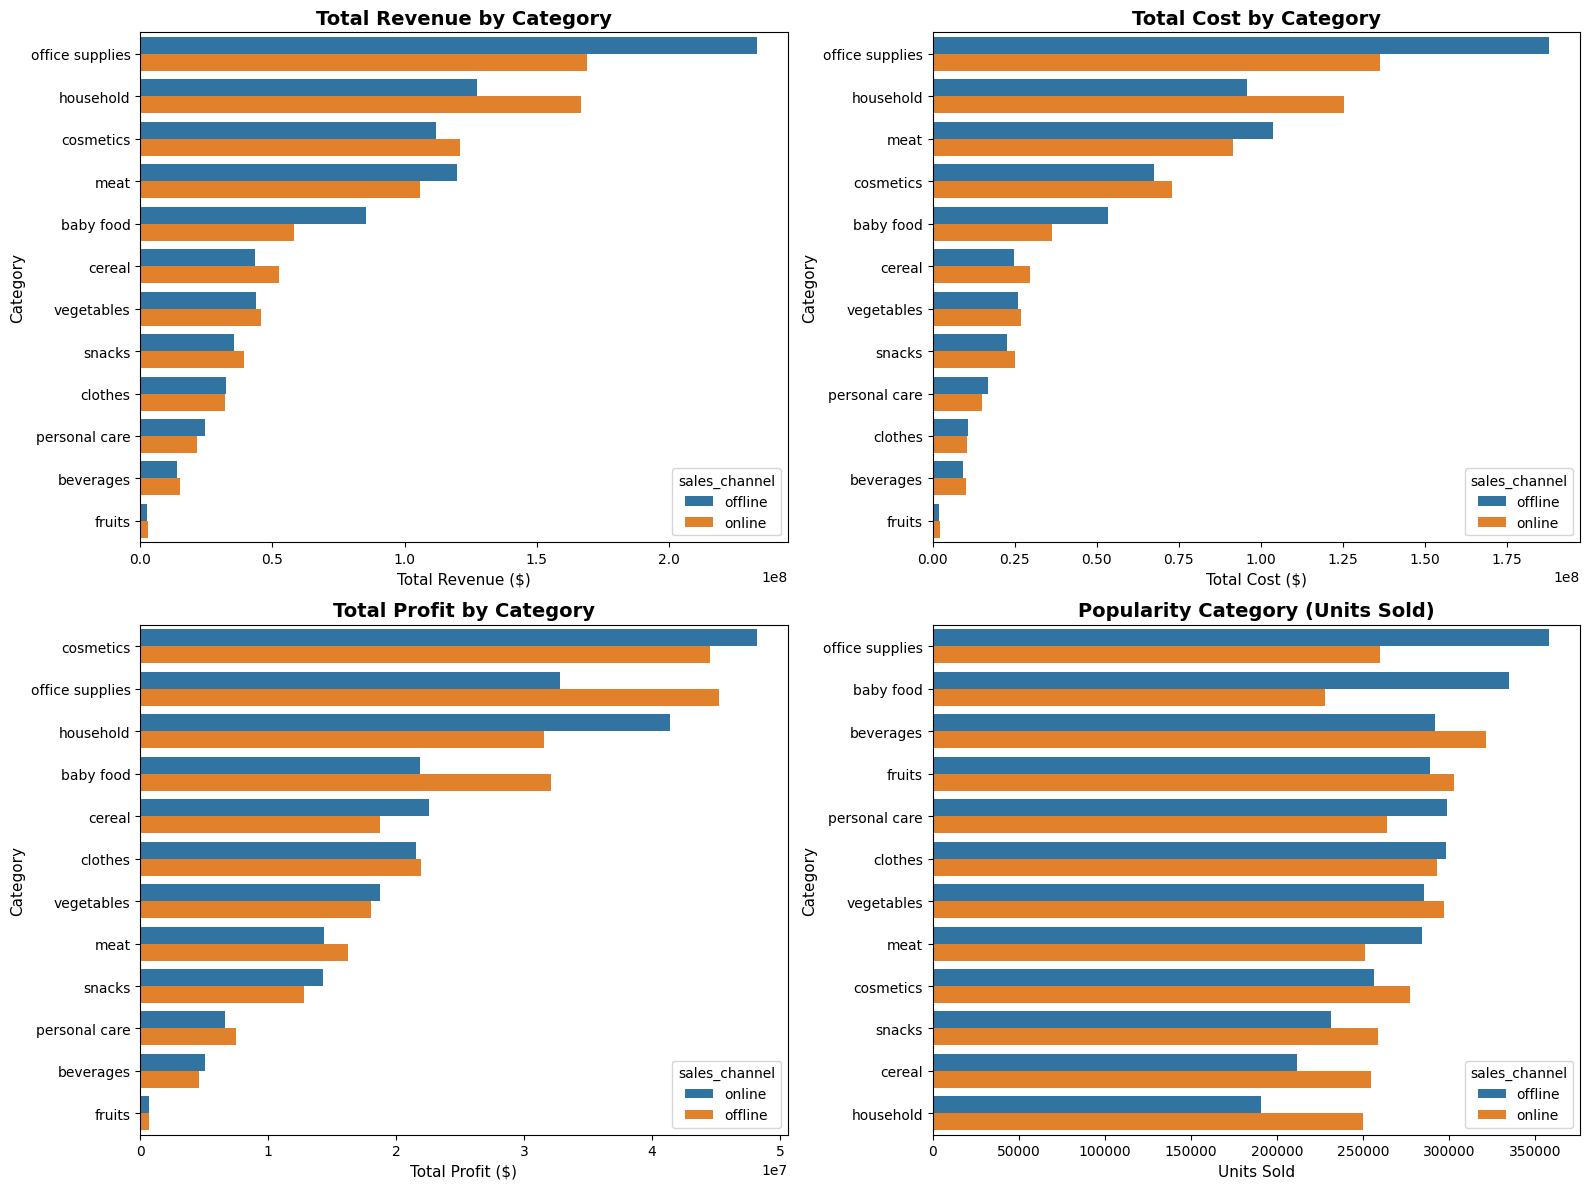

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(16, 12))

# TOTAL REVENUE
rev_df = (merged_df.groupby(["product_type", "sales_channel"])["revenue"].sum().sort_values(ascending=False).reset_index())
sns.barplot(x="revenue", y="product_type", data=rev_df, hue="sales_channel", errorbar=None, ax=ax[0, 0])
ax[0, 0].set_title("Total Revenue by Category", fontsize=14, fontweight="bold")
ax[0, 0].set_xlabel("Total Revenue ($)", fontsize=11)
ax[0, 0].set_ylabel("Category", fontsize=11)

#TOTAL COST
cost_df = (merged_df.groupby(["product_type", "sales_channel"])["cost"].sum().sort_values(ascending=False).reset_index())
sns.barplot(x="cost", y="product_type", data=cost_df, hue="sales_channel", errorbar=None, ax=ax[0, 1])
ax[0, 1].set_title("Total Cost by Category", fontsize=14, fontweight="bold")
ax[0, 1].set_xlabel("Total Cost ($)", fontsize=11)
ax[0, 1].set_ylabel("Category", fontsize=11)

#TOTAL PROFIT
profit_df = (merged_df.groupby(["product_type", "sales_channel"])["profit"].sum().sort_values(ascending=False).reset_index())
sns.barplot(x="profit", y="product_type", data=profit_df, hue="sales_channel", errorbar=None, ax=ax[1, 0])
ax[1, 0].set_title("Total Profit by Category", fontsize=14, fontweight="bold")
ax[1, 0].set_xlabel("Total Profit ($)", fontsize=11)
ax[1, 0].set_ylabel("Category", fontsize=11)

# UNITS SOLD
sold_df = (merged_df.groupby(["product_type", "sales_channel"])["units_sold"].sum().sort_values(ascending=False).reset_index())
sns.barplot(x="units_sold", y="product_type", data=sold_df, hue="sales_channel", errorbar=None, ax=ax[1, 1])
ax[1, 1].set_title("Popularity Category (Units Sold)", fontsize=14, fontweight="bold")
ax[1, 1].set_xlabel("Units Sold", fontsize=11)
ax[1, 1].set_ylabel("Category", fontsize=11)

plt.tight_layout()

plt.show()

##Проаналізуємо інтервал часу між замовленням та його відвантаженням та зробимо відповідні візуалізації в розрізі:

1. категорій товарів;
2. країн;
3. регіонів.

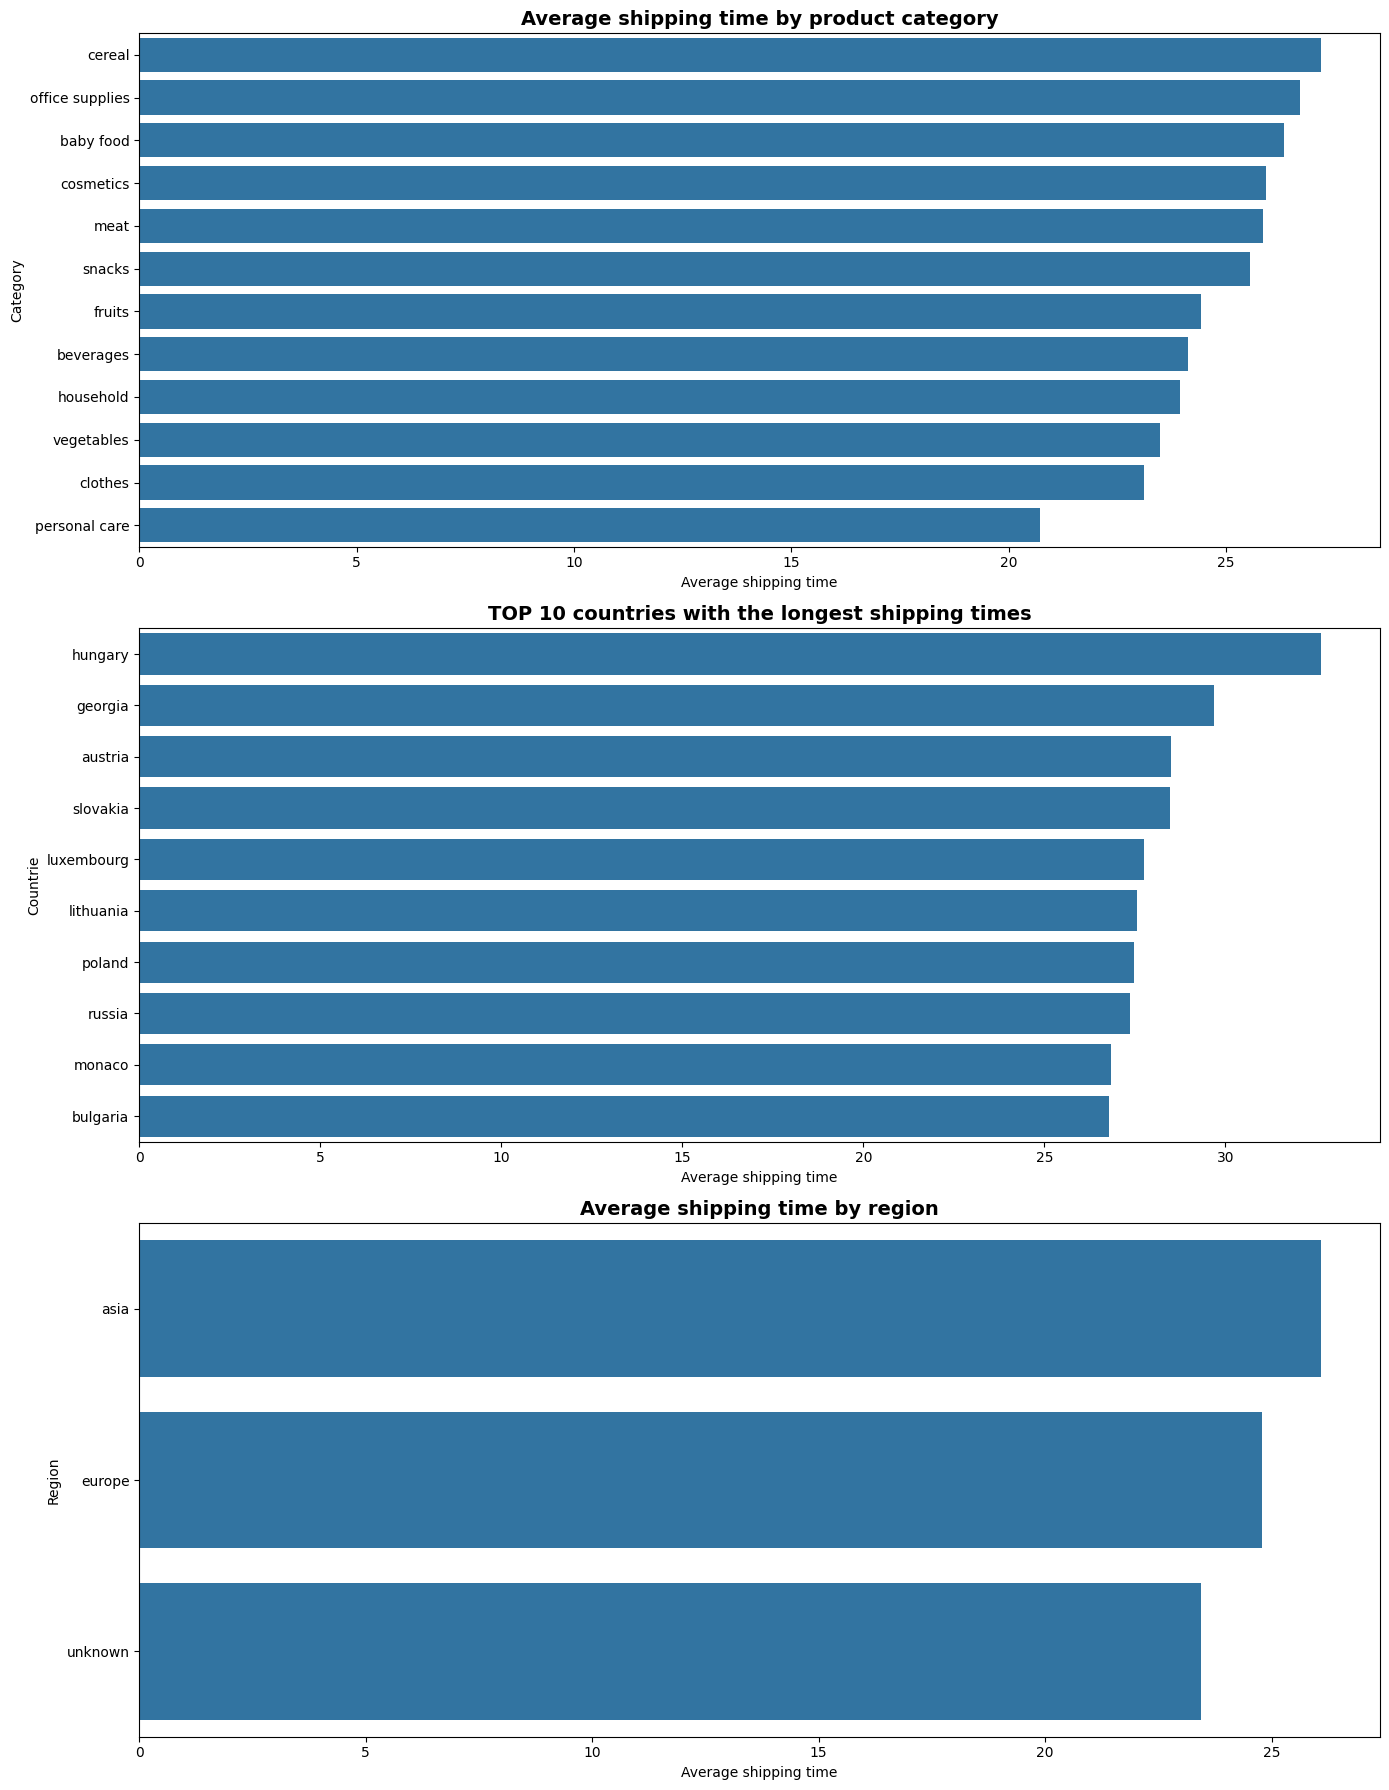

In [ ]:
merged_df["days_to_ship"] = (merged_df["ship_date"] - merged_df["order_date"]).dt.days


fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(14, 18))

# Category

df_product = (merged_df.groupby("product_type")["days_to_ship"].mean().sort_values(ascending=False).reset_index())
sns.barplot(x="days_to_ship", y="product_type", data=df_product, errorbar=None, ax=ax[0])
ax[0].set_title("Average shipping time by product category",fontsize=14,fontweight="bold")
ax[0].set_xlabel("Average shipping time")
ax[0].set_ylabel("Сategory")

# Сountrie (TOP 10)

df_country = (merged_df.groupby("country_name")["days_to_ship"].mean().sort_values(ascending=False).head(10).reset_index())
sns.barplot(x="days_to_ship", y="country_name", data=df_country, errorbar=None, ax=ax[1])
ax[1].set_title("TOP 10 countries with the longest shipping times",fontsize=14,fontweight="bold")
ax[1].set_xlabel("Average shipping time")
ax[1].set_ylabel("Сountrie")

# Region

df_region = (merged_df.groupby("region")["days_to_ship"].mean().sort_values(ascending=False).reset_index())
sns.barplot(x="days_to_ship", y="region", data=df_region, errorbar=None, ax=ax[2])
ax[2].set_title("Average shipping time by region", fontsize=14, fontweight="bold")
ax[2].set_xlabel("Average shipping time")
ax[2].set_ylabel("Region")

plt.tight_layout()
plt.show()

##Проаналізуємо, чи залежить прибуток від часу, необхідного на відвантаження товару.

/tmp/ipykernel_1247/4258822697.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  status_df = ( merged_df.groupby(["shipping_status"])["profit"].mean().reset_index())
/tmp/ipykernel_1247/4258822697.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="shipping_status", y="profit", data=status_df, palette="viridis", errorbar=None, ax=ax[1],)


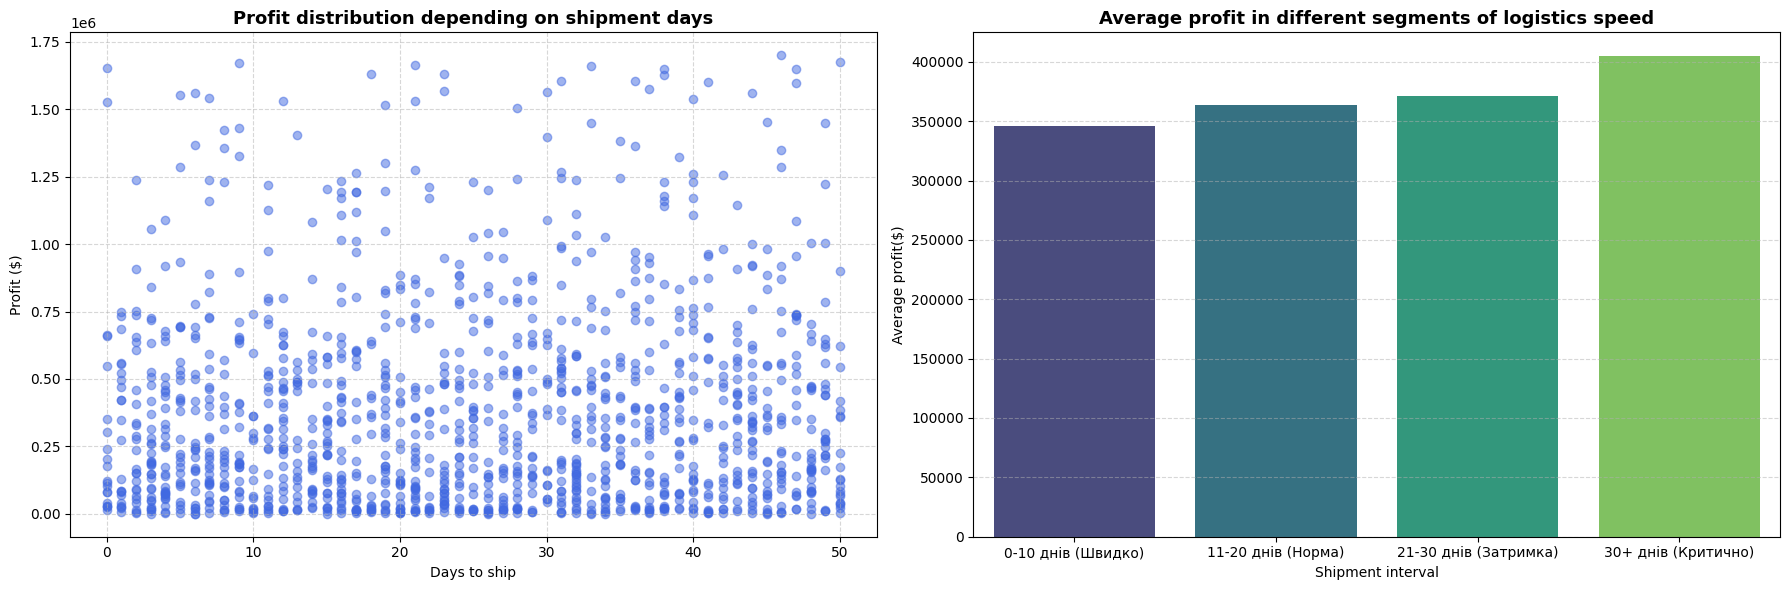

In [ ]:
bins = [-1, 10, 20, 30, 100]
labels = [
    "0-10 днів (Швидко)",
    "11-20 днів (Норма)",
    "21-30 днів (Затримка)",
    "30+ днів (Критично)",
]

merged_df["shipping_status"] = pd.cut(merged_df["days_to_ship"], bins=bins, labels=labels)


fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# (Scatter Plot)
ax[0].scatter(merged_df["days_to_ship"], merged_df["profit"], color="royalblue", alpha=0.5)
ax[0].set_title("Profit distribution depending on shipment days",fontsize=13,fontweight="bold")
ax[0].set_xlabel("Days to ship")
ax[0].set_ylabel("Profit ($)")
ax[0].grid(True, linestyle="--", alpha=0.5)

# Bar Plot
status_df = ( merged_df.groupby(["shipping_status"])["profit"].mean().reset_index())
sns.barplot(x="shipping_status", y="profit", data=status_df, palette="viridis", errorbar=None, ax=ax[1],)
ax[1].set_title("Average profit in different segments of logistics speed", fontsize=13, fontweight="bold")
ax[1].set_xlabel("Shipment interval")
ax[1].set_ylabel("Average profit($)")
ax[1].grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

##Проаналізуємо за допомогою візуалізації динаміку продажів (у часі) у розрізі категорій товарів, країн, регіонів, визначмо основні тенденції.

<Figure size 1600x800 with 0 Axes>

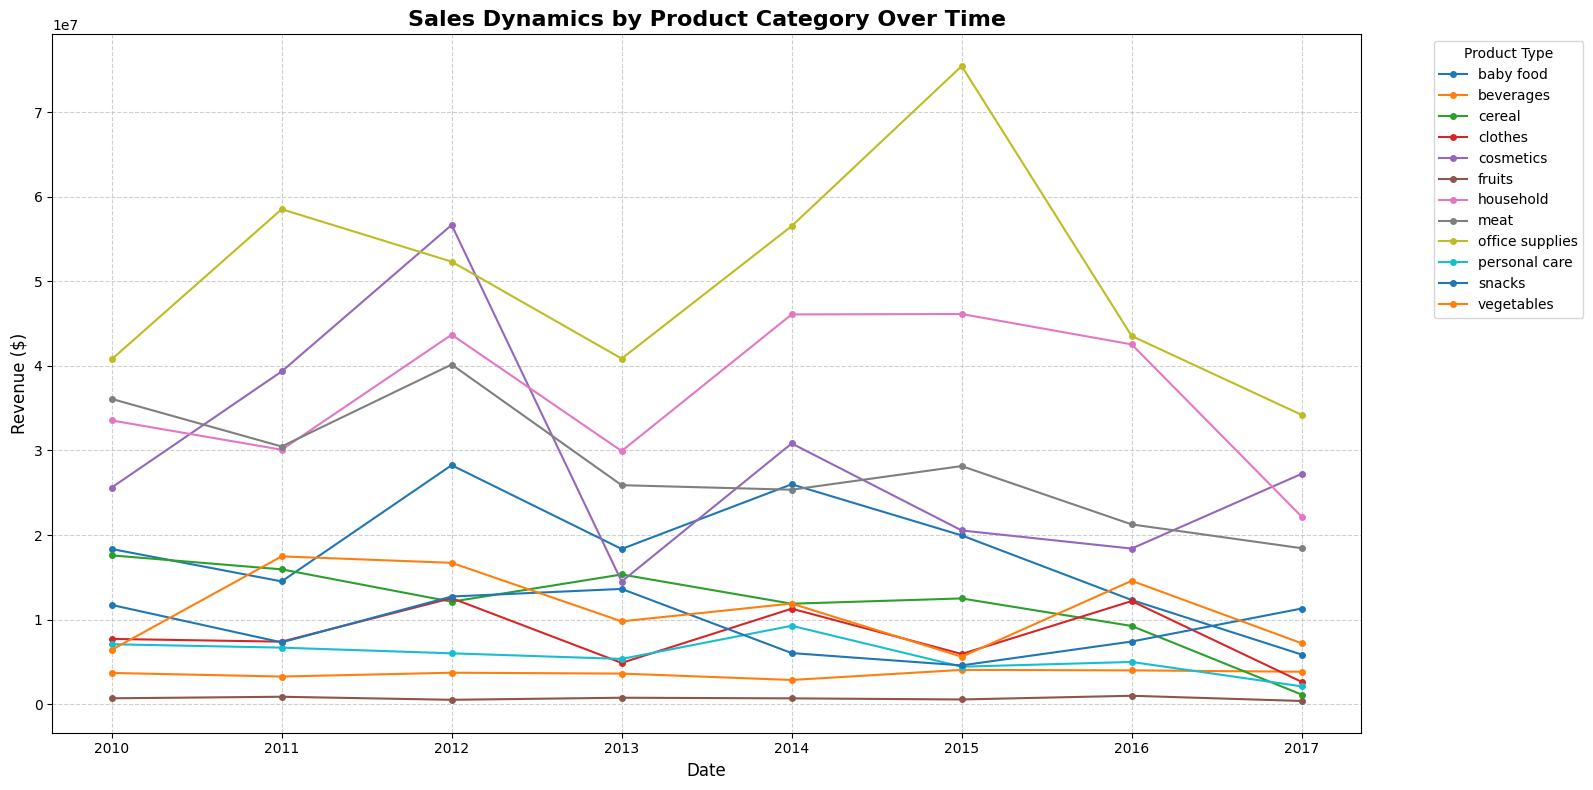

<Figure size 1600x800 with 0 Axes>

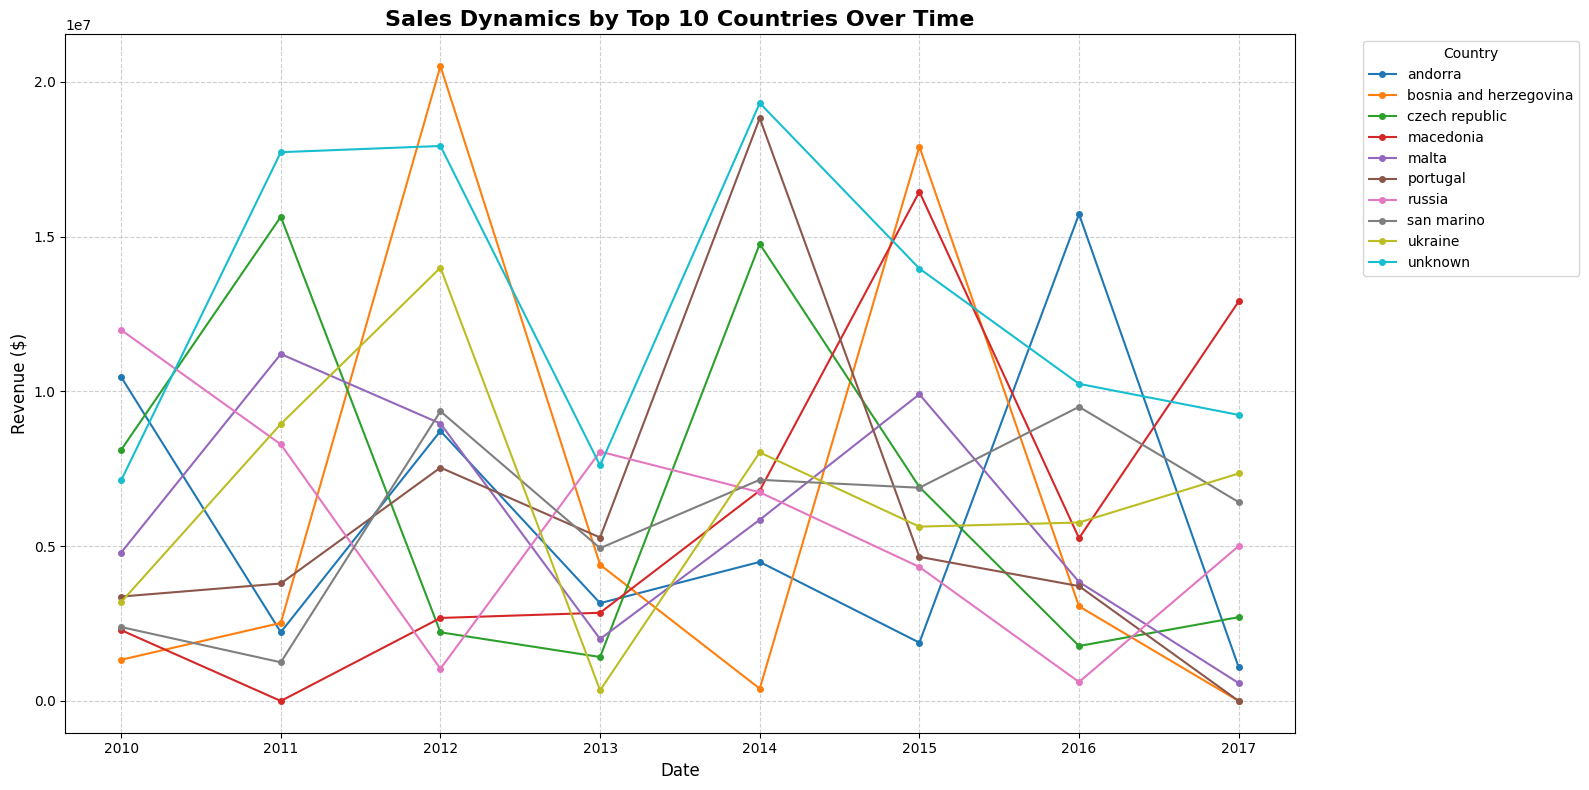

<Figure size 1600x800 with 0 Axes>

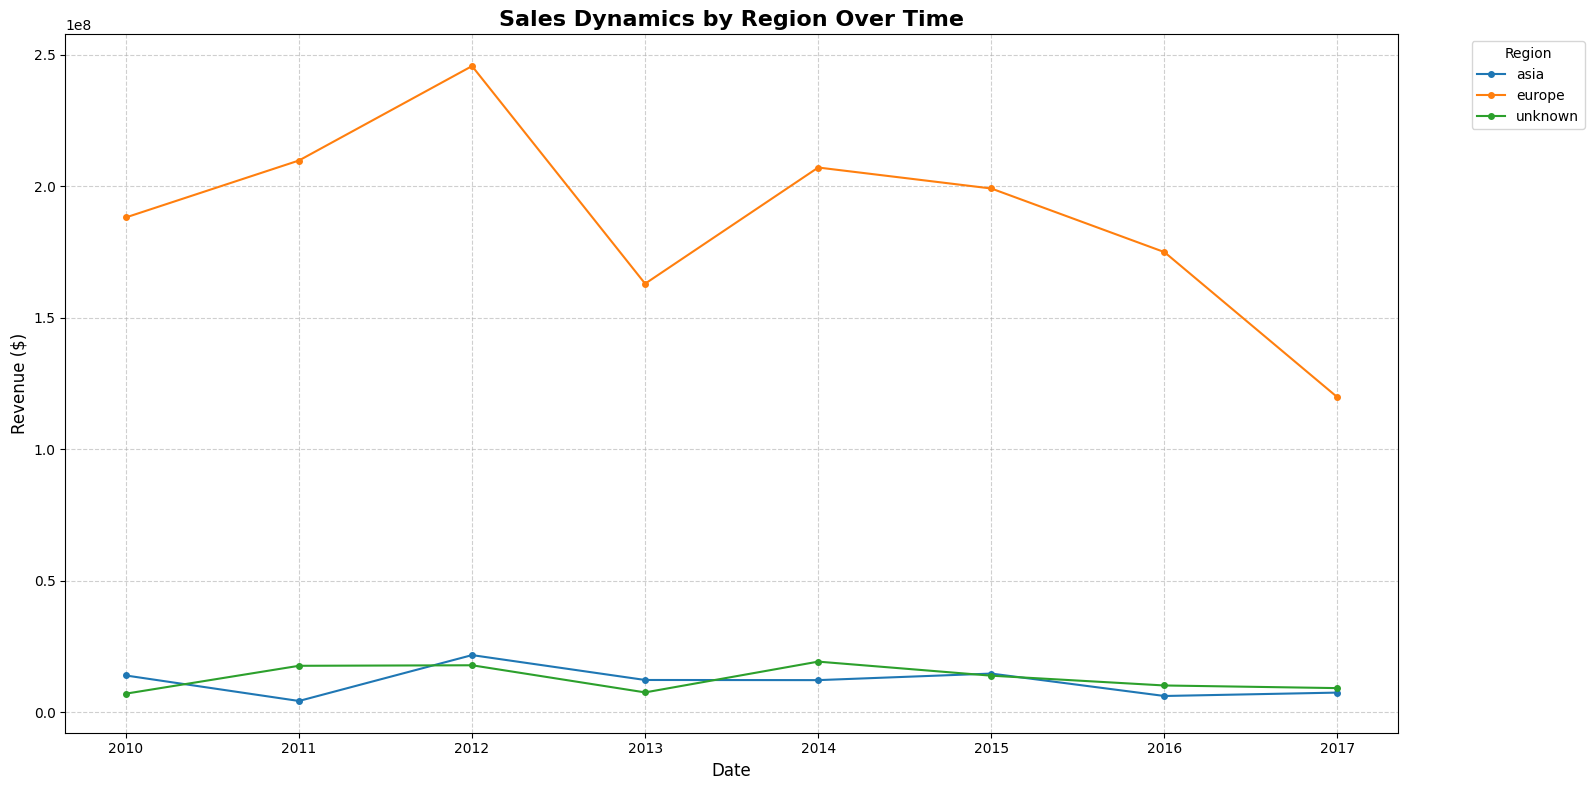

In [ ]:
merged_df["order_year"] = pd.to_datetime(merged_df["order_date"]).dt.year

# 1. Sales dynamics by product category

plt.figure(figsize=(16, 8))
sales_by_category = (merged_df.groupby(["order_year", "product_type"])["revenue"].sum().unstack(fill_value=0))
sales_by_category.plot(kind="line", figsize=(16, 8), marker="o", markersize=4)
plt.title("Sales Dynamics by Product Category Over Time", fontsize=16, fontweight="bold",)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Revenue ($)", fontsize=12)
plt.legend(title="Product Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# 2. Sales dynamics by country
top_10_countries = (merged_df.groupby("country_name")["revenue"].sum().nlargest(10).index)
plt.figure(figsize=(16, 8))
sales_by_country = (merged_df[merged_df["country_name"].isin(top_10_countries)].groupby(["order_year", "country_name"])["revenue"].sum().unstack(fill_value=0))
sales_by_country = sales_by_country.plot(kind="line", figsize=(16, 8), marker="o", markersize=4)
plt.title("Sales Dynamics by Top 10 Countries Over Time", fontsize=16, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Revenue ($)", fontsize=12)
plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# 3. Sales dynamics by region
plt.figure(figsize=(16, 8))
sales_by_region = (merged_df.groupby(["order_year", "region"])["revenue"].sum().unstack(fill_value=0))
sales_by_region.plot(kind="line", figsize=(16, 8), marker="o", markersize=4)
plt.title("Sales Dynamics by Region Over Time", fontsize=16, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Revenue ($)", fontsize=12)
plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()

plt.show()

##Проведемо аналіз продажів товарів за днями тижня.

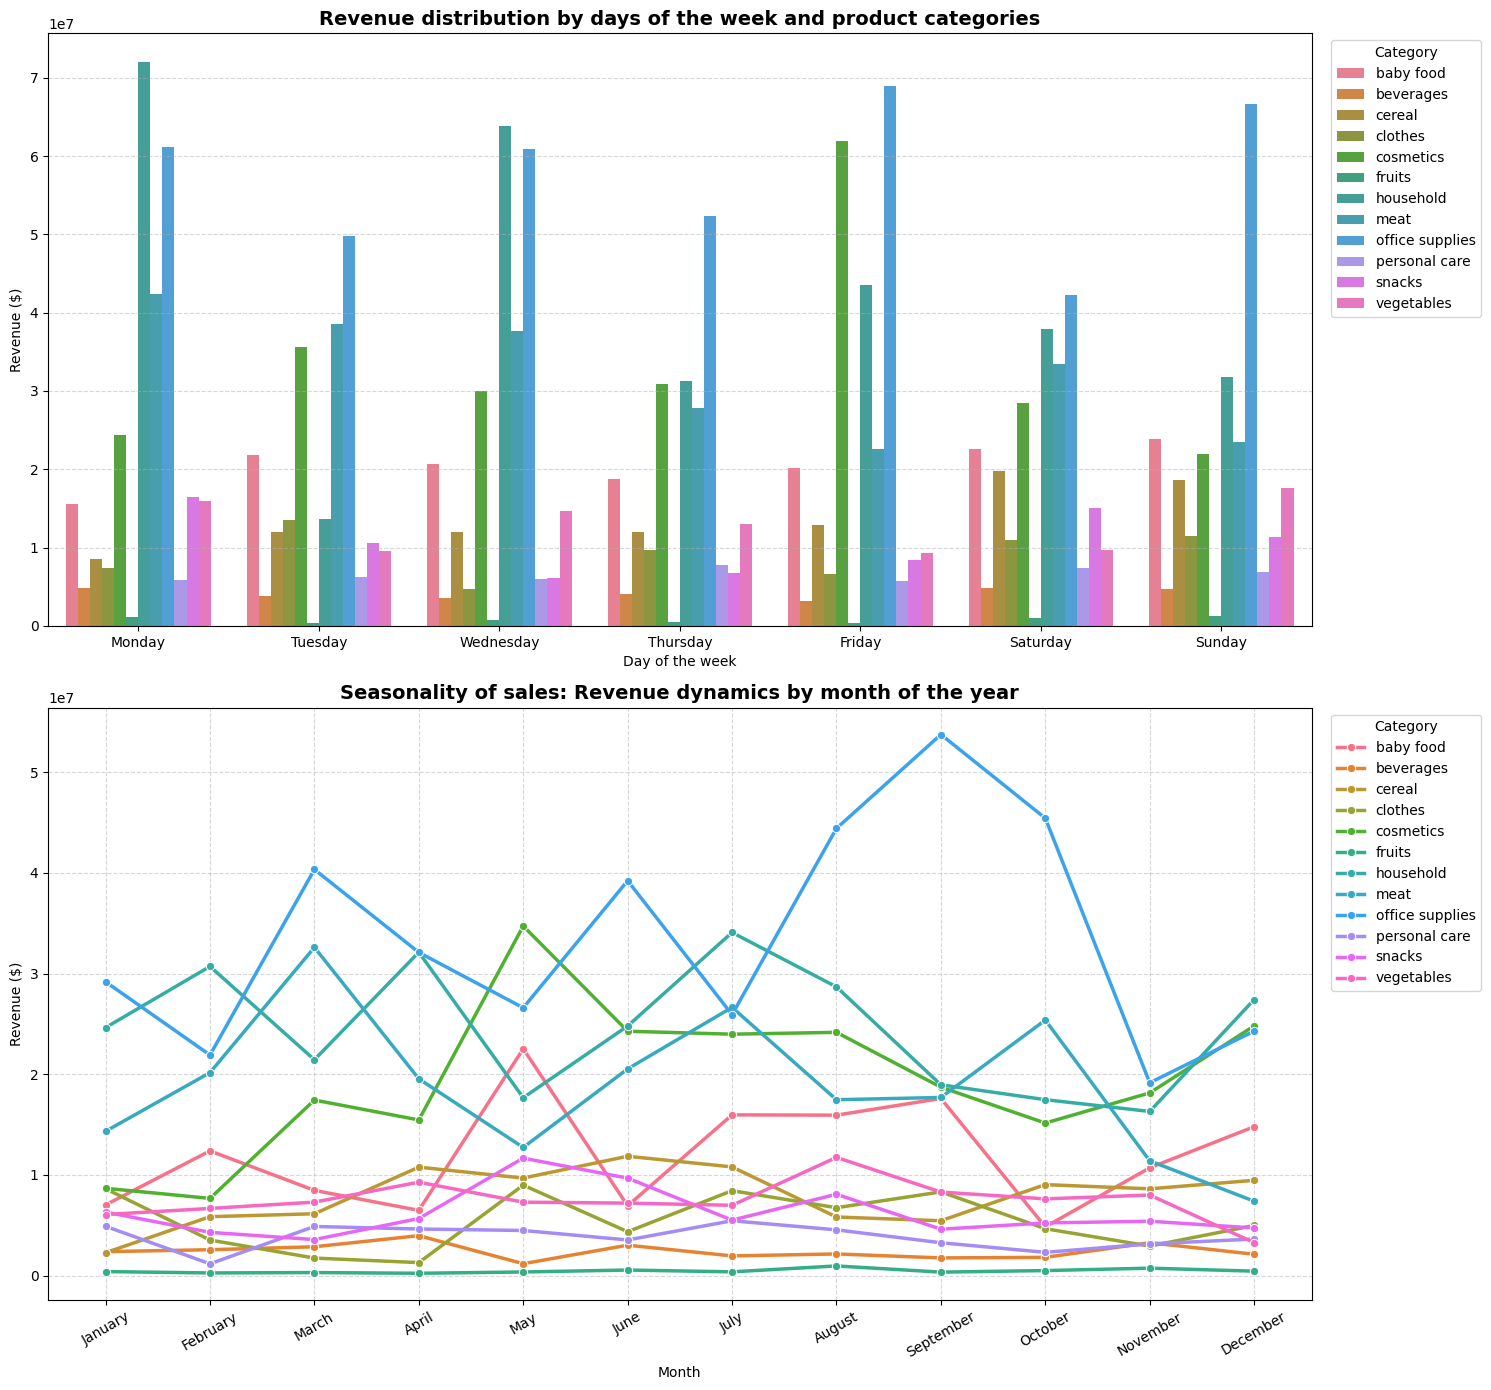

In [ ]:
merged_df["day_of_week"] = merged_df["order_date"].dt.day_name()
merged_df["month"] = merged_df["order_date"].dt.month_name()

days_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]
months_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
]


fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(15, 14))

# Sales analysis by day of the week
day_df = (merged_df.groupby(["day_of_week", "product_type"])["revenue"].sum().reset_index())
sns.barplot(x="day_of_week", y="revenue", hue="product_type", data=day_df, order=days_order, errorbar=None, ax=ax[0])
ax[0].set_title("Revenue distribution by days of the week and product categories", fontsize=14, fontweight="bold")
ax[0].set_xlabel("Day of the week")
ax[0].set_ylabel("Revenue ($)")
ax[0].legend(title="Category", bbox_to_anchor=(1.01, 1), loc="upper left")
ax[0].grid(axis="y", linestyle="--", alpha=0.5)

# Seasonality analysis
month_df = (merged_df.groupby(["month", "product_type"])["revenue"].sum().reset_index())
sns.lineplot(x="month", y="revenue", hue="product_type", data=month_df, sort=False, marker="o", linewidth=2.5, ax=ax[1])
ax[1].set_xticks(range(12))
ax[1].set_xticklabels(months_order, rotation=30)
ax[1].set_title("Seasonality of sales: Revenue dynamics by month of the year", fontsize=14, fontweight="bold")
ax[1].set_xlabel("Month")
ax[1].set_ylabel("Revenue ($)")
ax[1].legend(title="Category", bbox_to_anchor=(1.01, 1), loc="upper left")
ax[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()